# Evaluación 2 · Sección 3 — Análisis bivariado

Continuación de `Contreras_Daniela-Nicklichen_Emanuel_Evaluacion_2_S2_Descriptiva.ipynb`.

**Alcance de este notebook:** cubre las relaciones bivariadas simples (correlaciones, grupos, tablas de contingencia) y, en la sección 1.7, la determinación completa de "alternativa alcanzable" que responde directamente la pregunta de investigación — construida y validada por el equipo. La interpretación completa del resultado, como hallazgo formal, se desarrolla en la Sección 5.

## 1. Carga

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw" / "2026"

carpetas = {
    "Inscritos":       "PAES-2026-Inscritos-Puntajes",
    "Socioeconomico":  "PAES-2026-Socioeconomicos",
    "Postulantes":      "PAES-2026-Postulantes",
    "Matricula":        "PAES-2026-Matricula",
    "Oferta":           "PAES-2026-Oferta-Definitiva-Programas",
}

bases = {}
for nombre, carpeta in carpetas.items():
    archivo = list((RAW_DIR / carpeta).glob("*.csv"))[0]
    if nombre == "Oferta":
        bases[nombre] = pd.read_csv(archivo, sep=",", decimal=".")
    else:
        bases[nombre] = pd.read_csv(archivo, sep=";", decimal=",", low_memory=False)

A, B, C, D, O = bases["Inscritos"], bases["Socioeconomico"], bases["Postulantes"], bases["Matricula"], bases["Oferta"]

# Mapeo de codigo a nombre de dependencia, usado en toda la seccion
dep_map = {"1":"Corp. Municipal","2":"Municipal","3":"Part. Subvencionado",
           "4":"Part. Pagado","5":"Corp. Adm. Delegada","6":"SLEP"}
A["DEP_NOMBRE"] = A["DEPENDENCIA"].astype(str).str.strip().map(dep_map)

## 1.2 Correlación entre las pruebas de puntaje: Pearson y Spearman

Se calcula sobre quienes rindieron las **5 pruebas simultáneamente** — no es la población completa (excluye a quienes no dieron alguna optativa), así que es una subpoblación específica, más orientada a carreras que exigen ciencias/historia y M2 en conjunto.

In [20]:
pruebas = ["CLEC_MAX", "MATE1_MAX", "MATE2_MAX", "HCSOC_MAX", "CIEN_MAX"]
cuant = pruebas + ["PTJE_NEM", "PTJE_RANKING"]

# Filtramos a quienes tienen puntaje > 0 en las 5 pruebas a la vez
rindio_todas = A[(A[pruebas] > 0).all(axis=1)]
print(f"Rindieron las 5 pruebas: {len(rindio_todas)} ({len(rindio_todas)/len(A)*100:.2f}% del total)")

pearson = rindio_todas[cuant].corr(method="pearson")
pearson.round(3)

Rindieron las 5 pruebas: 48234 (15.07% del total)


,CLEC_MAX,MATE1_MAX,MATE2_MAX,HCSOC_MAX,CIEN_MAX,PTJE_NEM,PTJE_RANKING
CLEC_MAX,1.000,0.760,0.486,0.714,0.721,0.456,0.443
MATE1_MAX,0.760,1.000,0.634,0.609,0.759,0.451,0.432
MATE2_MAX,0.486,0.634,1.000,0.448,0.621,0.282,0.265
HCSOC_MAX,0.714,0.609,0.448,1.000,0.605,0.346,0.335
CIEN_MAX,0.721,0.759,0.621,0.605,1.000,0.407,0.390
PTJE_NEM,0.456,0.451,0.282,0.346,0.407,1.000,0.992
PTJE_RANKING,0.443,0.432,0.265,0.335,0.390,0.992,1.000


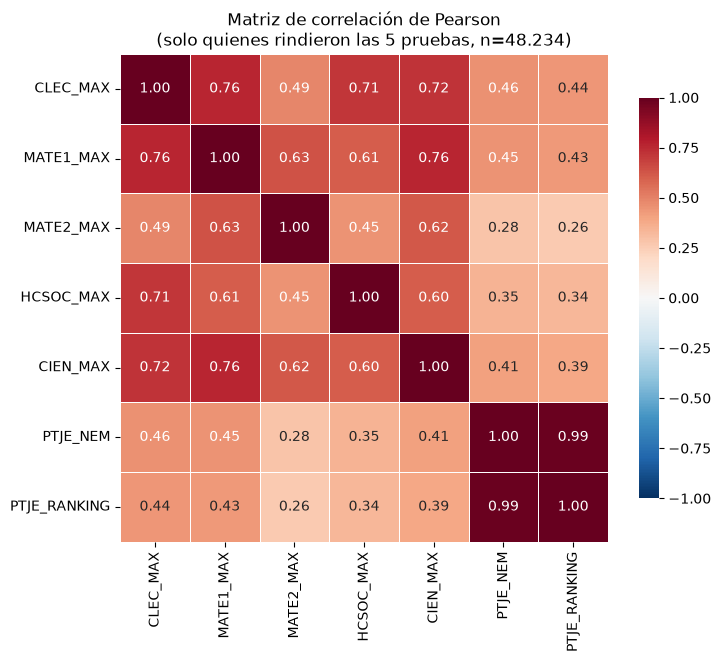

In [21]:
# Heatmap con seaborn (mismo criterio visto en clase): annot=True muestra
# el valor de cada celda directamente, mas simple que anotar a mano con matplotlib
import seaborn as sns

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación de Pearson\n(solo quienes rindieron las 5 pruebas, n=48.234)")
plt.tight_layout()
plt.show()

`PTJE_NEM` y `PTJE_RANKING` correlacionan en 0,99 — son casi la misma información (el ranking se calcula a partir de la posición del NEM dentro del establecimiento). Entre las pruebas, `MATE1_MAX` y `CIEN_MAX` son las más asociadas (0,76); `MATE2_MAX` es la que menos se parece al resto (0,45-0,63), consistente con ser la más autoseleccionada.

### Correlación no implica causalidad, y un mismo coeficiente puede esconder formas muy distintas

Dos advertencias necesarias antes de seguir interpretando coeficientes:

**Correlación no es causalidad.** Que `MATE1_MAX` y `CIEN_MAX` correlacionen en 0,76 no significa que una cause la otra — lo más probable es que ambas reflejen una habilidad académica general subyacente que no estamos midiendo directamente. Ninguna interpretación de esta sección afirma que una variable "produce" el valor de otra, solo que se mueven juntas.

**Un mismo coeficiente puede esconder formas completamente distintas.** El ejemplo clásico es el Cuarteto de Anscombe (Anscombe, 1973): cuatro conjuntos de datos con la misma media, la misma correlación de Pearson (r≈0,816) y la misma recta de regresión, pero con formas visuales radicalmente distintas.

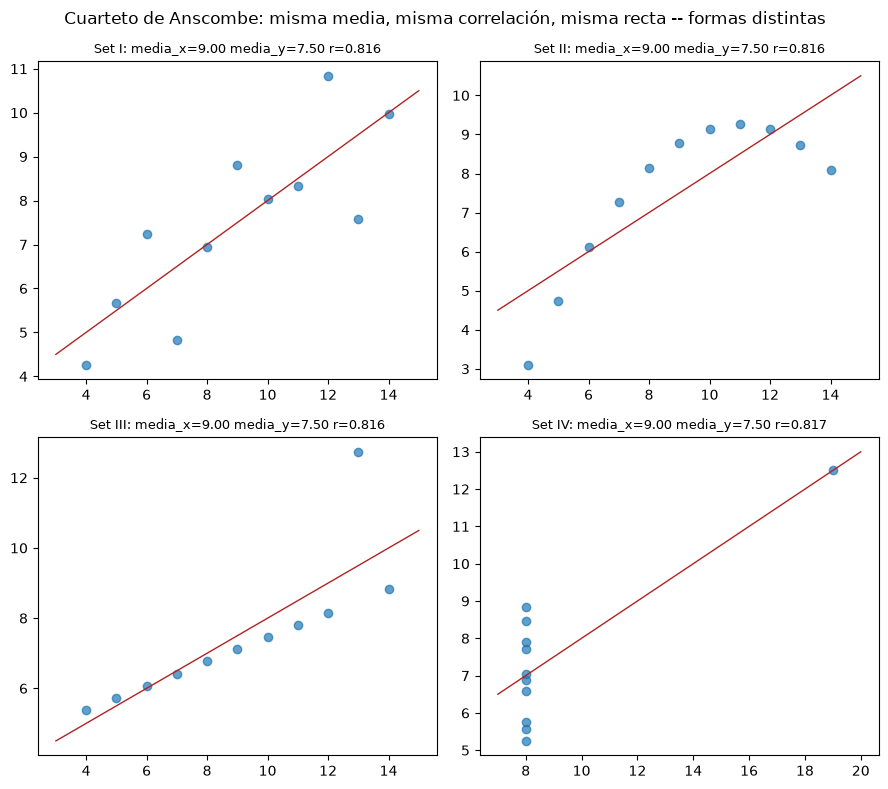

In [22]:
# Cuarteto de Anscombe: valores clasicos (no son datos del proyecto), se usan
# solo como ilustracion de por que no basta con mirar el coeficiente.
x123 = np.array([10,8,13,9,11,14,6,4,12,7,5])
y1 = np.array([8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68])
y2 = np.array([9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74])
y3 = np.array([7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73])
x4 = np.array([8,8,8,8,8,8,8,19,8,8,8])
y4 = np.array([6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89])
datasets = [(x123,y1,"I"), (x123,y2,"II"), (x123,y3,"III"), (x4,y4,"IV")]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (x, y, nombre) in zip(axes.flat, datasets):
    r, _ = stats.pearsonr(x, y)
    m, b = np.polyfit(x, y, 1)  # recta por minimos cuadrados, solo para dibujarla
    ax.scatter(x, y, alpha=0.7)
    xs = np.linspace(x.min()-1, x.max()+1, 50)
    ax.plot(xs, m*xs+b, color="firebrick", linewidth=1)
    ax.set_title(f"Set {nombre}: media_x={x.mean():.2f} media_y={y.mean():.2f} r={r:.3f}", fontsize=9)
plt.suptitle("Cuarteto de Anscombe: misma media, misma correlación, misma recta -- formas distintas")
plt.tight_layout()
plt.show()

El Set I es una relación lineal genuina. El Set II es una curva (Pearson no detecta no-linealidad). El Set III tiene un solo atípico que arrastra toda la recta. El Set IV es un caso extremo: **un único punto** sostiene la correlación completa — sin él, no habría relación. La lección para nuestro propio análisis: un coeficiente de 0,76 entre `MATE1_MAX` y `CIEN_MAX` no dice nada sobre la *forma* de esa relación — por eso siempre acompañamos el número con un gráfico o una comparación con/sin atípicos, no lo dejamos solo.

### Contraste con y sin atípicos: no siempre conviene sacarlos

In [23]:
# CLEC_MAX vs MATE2_MAX, entre quienes rindieron ambas -- MATE2_MAX es la
# prueba con mas atipicos marcados en la Seccion 2 (4.38%). Comparamos el
# coeficiente de Pearson con y sin esos atipicos (criterio IQR ya usado antes).
sub = A[(A["CLEC_MAX"]>0) & (A["MATE2_MAX"]>0)]

r_con, _ = stats.pearsonr(sub["CLEC_MAX"], sub["MATE2_MAX"])

q1, q3 = sub["MATE2_MAX"].quantile([0.25, 0.75])
iqr = q3 - q1
sin_atipicos = sub[(sub["MATE2_MAX"] >= q1-1.5*iqr) & (sub["MATE2_MAX"] <= q3+1.5*iqr)]
r_sin, _ = stats.pearsonr(sin_atipicos["CLEC_MAX"], sin_atipicos["MATE2_MAX"])

print(f"Pearson CON atipicos (n={len(sub)}):    {r_con:.3f}")
print(f"Pearson SIN atipicos (n={len(sin_atipicos)}): {r_sin:.3f}")
print(f"Diferencia: {abs(r_con - r_sin):.3f}")

Pearson CON atipicos (n=124506):    0.547
Pearson SIN atipicos (n=119257): 0.486
Diferencia: 0.061


La diferencia es real (0,061) pero no cambia la conclusión cualitativa: la relación sigue siendo moderada y positiva con o sin atípicos. En este caso, no había una razón de peso para sacarlos —no distorsionaban la lectura general—, así que se documenta el contraste y se sigue trabajando con el conjunto completo. La regla no es "sacar atípicos siempre" ni "nunca sacarlos": es medir el efecto y decidir con ese número en la mano, no antes.

### ¿Cuándo Spearman en vez de Pearson? — con evidencia de esta misma sección

In [24]:
# Spearman usa rangos en vez de valores, por lo que es menos sensible a
# atipicos y a relaciones no lineales. Comparamos ambas para ver donde difieren.
spearman = rindio_todas[cuant].corr(method="spearman")
diferencia = (spearman - pearson).abs()
print("Mayor diferencia absoluta entre Spearman y Pearson, por variable:")
print(diferencia.max().sort_values(ascending=False).round(3))

Mayor diferencia absoluta entre Spearman y Pearson, por variable:
MATE2_MAX       0.185
CIEN_MAX        0.185
MATE1_MAX       0.123
HCSOC_MAX       0.100
CLEC_MAX        0.074
PTJE_NEM        0.035
PTJE_RANKING    0.031
dtype: float64


`MATE2_MAX` y `CIEN_MAX` son las que más difieren entre Pearson y Spearman (hasta 0,185) — y son, justamente, las dos pruebas que en la Sección 2 mostraron más atípicos (4,38% y 5,22%) y mayor asimetría entre quienes rindieron (1,431 y 1,185). No es coincidencia: es el caso de manual de cuándo Spearman es la medida más confiable — cuando hay atípicos, Pearson se deja influir más por ellos que Spearman.

## 1.3 Puntaje y nivel socioeconómico

In [25]:
# Cruzamos A con el decil de ingreso (B), excluyendo el codigo 99 (Seccion 1)
AB = A.merge(B[["MRUN","INGRESO_PERCAPITA_GRUPO_FA"]], on="MRUN", how="left")
AB_valido = AB[AB["INGRESO_PERCAPITA_GRUPO_FA"] != 99]

# Spearman en vez de Pearson: el decil es ordinal, no una escala continua real
for col in ["CLEC_MAX", "MATE1_MAX"]:
    sub = AB_valido[AB_valido[col] > 0]
    r, p = stats.spearmanr(sub["INGRESO_PERCAPITA_GRUPO_FA"], sub[col])
    print(f"{col} vs decil de ingreso: Spearman r = {r:.3f} (p={p:.1e})")

CLEC_MAX vs decil de ingreso: Spearman r = 0.153 (p=0.0e+00)
MATE1_MAX vs decil de ingreso: Spearman r = 0.161 (p=0.0e+00)


Correlación débil (0,15-0,16) pero estadísticamente significativa — con una muestra de más de 200 mil casos, hasta relaciones débiles resultan "significativas"; **el tamaño del coeficiente importa más que el p-valor** para juzgar si la relación es relevante en la práctica. Se revisa la tendencia directamente en las medias por decil:

In [26]:
# Tendencia por decil: promedio y mediana de CLEC_MAX, no solo el coeficiente
sub = AB_valido[AB_valido["CLEC_MAX"] > 0]
sub.groupby("INGRESO_PERCAPITA_GRUPO_FA")["CLEC_MAX"].agg(Media="mean",Mediana="median",Cantidad="count").round(1)

,Media,Mediana,Cantidad
INGRESO_PERCAPITA_GRUPO_FA,,,
1,585.2,583.0,36200
2,604.9,597.0,28787
3,617.3,607.0,20745
4,621.8,607.0,19156
5,619.9,607.0,15238
6,620.0,607.0,13960
7,601.4,590.0,21514
8,610.1,597.0,18008
9,643.2,634.0,13109


**Interpretando solo lo que se ve:** hay una tendencia general al alza (585 en el decil 1 hasta 706 en el decil 10), pero no es estrictamente monótona — el decil 7 baja a 601, por debajo incluso de los deciles 3 a 6. El salto más grande y claro está entre el decil 9 (643) y el 10 (706); en el resto, las diferencias son modestas. No se fuerza una lectura de "a mayor ingreso, siempre mayor puntaje" — el patrón es una tendencia con excepciones, no una escalera perfecta.

## 1.4 Puntaje y dependencia del establecimiento (grupos)

In [27]:
# Mismo calculo que 1.3, ahora agrupando por dependencia en vez de decil de ingreso
orden = ["Corp. Adm. Delegada","SLEP","Municipal","Corp. Municipal","Part. Subvencionado","Part. Pagado"]
sub = A[(A["CLEC_MAX"]>0) & (A["DEP_NOMBRE"].notna())]
sub.groupby("DEP_NOMBRE")["CLEC_MAX"].agg(Media="mean",Mediana="median",Cantidad="count").round(1).reindex(orden)

,Media,Mediana,Cantidad
DEP_NOMBRE,,,
Corp. Adm. Delegada,562.3,555.0,8127
SLEP,571.0,567.0,27040
Municipal,578.4,576.0,39856
Corp. Municipal,597.7,589.0,16329
Part. Subvencionado,613.1,598.0,148944
Part. Pagado,722.6,725.0,34168


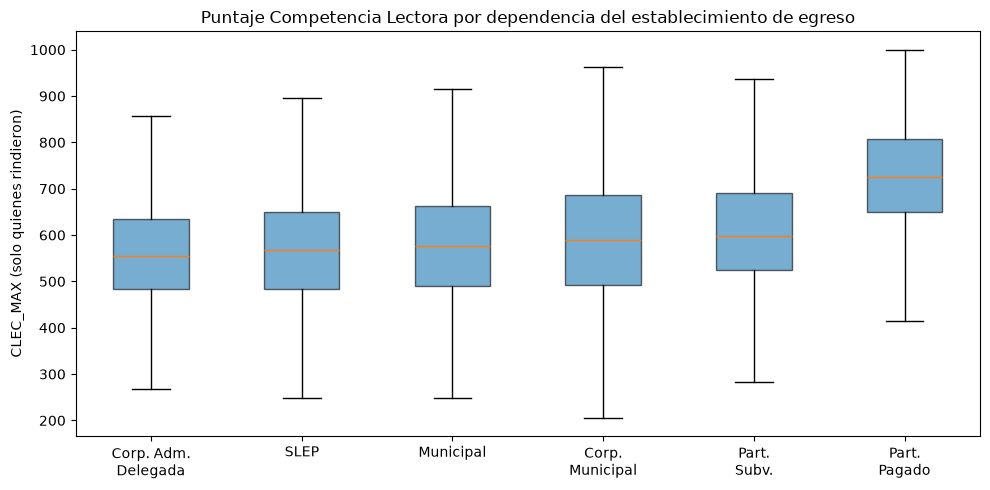

In [28]:
# Boxplot de la tabla anterior, ordenado de menor a mayor mediana observada
orden_corto = ["Corp. Adm.\nDelegada","SLEP","Municipal","Corp.\nMunicipal","Part.\nSubv.","Part.\nPagado"]
A["DEP_CORTO"] = A["DEPENDENCIA"].astype(str).str.strip().map(
    dict(zip(["5","6","2","1","3","4"], orden_corto)))
datos = [A.loc[(A["CLEC_MAX"]>0) & (A["DEP_CORTO"]==d), "CLEC_MAX"] for d in orden_corto]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(datos, tick_labels=orden_corto, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#1f77b4"); patch.set_alpha(0.6)
ax.set_ylabel("CLEC_MAX (solo quienes rindieron)")
ax.set_title("Puntaje Competencia Lectora por dependencia del establecimiento de egreso")
plt.tight_layout()
plt.show()

La brecha es de 160 puntos entre los extremos (562 en Corp. Administración Delegada, 723 en Particular Pagado). Cinco de las seis categorías tienen cajas y medianas muy parecidas entre sí (555-598); Particular Pagado es la que se despega claramente del resto, no un gradiente parejo entre las seis.

## 1.5 Dependencia y habilitación para postular (tabla de contingencia)

Para cruzar dos variables categóricas existen tres herramientas equivalentes en pandas (`.groupby`, `pd.pivot_table`, `pd.crosstab`); se usa `pd.crosstab` en toda esta sección porque viene pensada específicamente para tablas de contingencia — permite normalizar por fila directamente (`normalize="index"`) sin pasos adicionales, a diferencia de `.groupby`, que requiere calcular el porcentaje a mano.

In [29]:
# Tabla de contingencia DEPENDENCIA x HABILITACION_POST, en porcentaje por fila
tabla_hab = pd.crosstab(A["DEP_NOMBRE"], A["HABILITACION_POST"].map({1:"Habilitado",2:"Excepcion",3:"No habilitado"}))
tabla_hab_pct = pd.crosstab(A["DEP_NOMBRE"], A["HABILITACION_POST"].map({1:"Habilitado",2:"Excepcion",3:"No habilitado"}), normalize="index")*100
tabla_hab_pct.round(1).reindex(orden)

HABILITACION_POST,Excepcion,Habilitado,No habilitado
DEP_NOMBRE,,,
Corp. Adm. Delegada,0.0,61.3,38.6
SLEP,0.4,63.2,36.5
Municipal,0.2,67.5,32.2
Corp. Municipal,0.3,68.0,31.6
Part. Subvencionado,0.2,78.3,21.6
Part. Pagado,0.0,94.7,5.3


**Este es el hallazgo más claro de la sección.** Solo un 5,3% de los estudiantes de establecimientos particulares pagados queda "no habilitado" para postular, frente a 38,6% en Corporación de Administración Delegada, 36,5% en SLEP y ~32% en municipal/corporación municipal — más de 7 veces la tasa. Recordar que `HABILITACION_POST` se calcula directamente desde `CLEC_MAX`/`MATE1_MAX` (Sección 1) — esta tabla es, en el fondo, otra forma de ver la misma brecha de puntaje de 1.4, no una relación independiente nueva.

## 1.6 Dependencia y resultado de la preferencia (tabla de contingencia)

In [30]:
def agrupar_estado(codigo):
    if codigo == 24: return "Seleccionada"
    elif codigo == 25: return "En lista de espera"
    elif codigo == 26: return "No evaluada (ya seleccionado antes)"
    elif codigo in [9,15,17,19,20,22,23,51,52]: return "Anulada: no cumple requisito previo"
    else: return "Anulada: falta puntaje o promedio minimo"

C["ESTADO_GRUPO"] = C["ESTADO_PREF"].apply(agrupar_estado)

# Solo preferencias REGULARES (BEA/PACE/GENERO tienen cortes distintos, Formulacion)
C_dep = C.merge(A[["MRUN","DEP_NOMBRE"]], on="MRUN", how="left")
C_dep = C_dep[(C_dep["TIPO_PREF"]=="REGULAR") & (C_dep["DEP_NOMBRE"].notna())]

tabla_estado = pd.crosstab(C_dep["DEP_NOMBRE"], C_dep["ESTADO_GRUPO"], normalize="index")*100

cols_orden = ["Seleccionada","En lista de espera","No evaluada (ya seleccionado antes)",
              "Anulada: falta puntaje o promedio minimo","Anulada: no cumple requisito previo"]

tabla_estado[cols_orden].round(1).reindex(orden)

ESTADO_GRUPO,Seleccionada,En lista de espera,No evaluada (ya seleccionado antes),Anulada: falta puntaje o promedio minimo,Anulada: no cumple requisito previo
DEP_NOMBRE,,,,,
Corp. Adm. Delegada,9.1,23.5,57.1,8.9,1.4
SLEP,10.5,21.6,57.9,8.8,1.1
Municipal,10.0,23.1,58.5,7.8,0.6
Corp. Municipal,9.6,25.1,57.6,6.3,1.5
Part. Subvencionado,11.1,24.4,59.0,4.7,0.8
Part. Pagado,13.3,27.2,57.7,1.1,0.7


**Aquí el patrón es más sutil, y hay que decirlo con precisión.** La tasa de preferencias seleccionadas varía poco entre dependencias (9,1% a 13,3%), y la de "no evaluada" es prácticamente idéntica (57-59%), por lo que es correcto decir que el mecanismo de asignación opera igual para todos. La brecha aparece en la columna de anulación por falta de puntaje o promedio mínimo: 1,1% en Particular Pagado contra 8,9% en Corporación de Administración Delegada y 8,8% en SLEP, ocho veces más. No es que a estos estudiantes les vaya peor en la competencia por el cupo: es que una parte de sus preferencias ni siquiera llega a competir, por no tener rendida alguna prueba exigida o no alcanzar el promedio de 458. Es la misma brecha de 1.5 vista desde el lado de la postulación.

**Lo que esto no dice:** esta tabla mide el resultado de las preferencias que cada estudiante *sí* incluyó en su lista — no dice nada todavía sobre si existían programas alcanzables que el estudiante *no* incluyó, que es la pregunta central del proyecto.

## 1.7 La pregunta de investigación directa: ¿tenían alternativa alcanzable?

Todo lo anterior son relaciones que apuntan hacia la pregunta del proyecto. Esta sección la responde directamente: para cada uno de los 27.492 postulantes que no quedaron en ninguna preferencia, se calcula su puntaje ponderado contra la oferta completa (no solo contra lo que puso en su lista) y se compara contra el puntaje de corte real de cada programa.

### Paso 1 y 2: construir la fórmula del puntaje ponderado, y validarla contra la realidad

Cada programa en `Oferta` declara su ponderación (NEM, Ranking, CLEC, M1, Historia/Ciencias, M2, en %). Dos detalles ya resueltos en secciones anteriores hay que incorporar a la fórmula:

- **Historia y Ciencias son un cupo único, no dos que se suman** (Sección 1): cuando un programa acepta ambas pruebas, se usa el mejor puntaje del estudiante entre las dos, con el peso mayor entre ambas columnas — no la suma.
- **Postulantes extranjeros sin NEM** (fuente: DEMRE, "Postulantes extranjeros sin Notas de Enseñanza Media"): quienes cursaron toda su enseñanza media en el extranjero no tienen NEM ni Ranking chilenos. DEMRE no les asigna 0 en esos componentes — redistribuye proporcionalmente ese porcentaje entre las demás pruebas, de modo que sigan sumando 100%. En nuestros datos, esto corresponde a los estudiantes con `PTJE_NEM=0` o `PTJE_RANKING=0` (1,91% del total, documentado como pendiente en la Sección 2).

In [31]:
# Construimos el puntaje ponderado de cada preferencia REGULAR, para validarlo
# contra el PTJE_PREF real que ya viene en la base.
regular = C[C["TIPO_PREF"] == "REGULAR"].copy()
regular = regular.merge(O[["COD_CARRERA","CARRERA","NEM","RANKING","CLEC","M1","HSCO","CIEN","M2"]],
                         left_on="COD_CARRERA_PREF", right_on="COD_CARRERA", how="left")
regular = regular.merge(A[["MRUN","PTJE_NEM","PTJE_RANKING","CLEC_MAX","MATE1_MAX","MATE2_MAX","HCSOC_MAX","CIEN_MAX"]],
                         on="MRUN", how="left")

# Historia/Ciencias: cupo unico. Si el programa pide ambas, se usa el mejor
# puntaje del estudiante; si pide solo una, se usa esa prueba especifica.
w_hsco = regular["HSCO"].fillna(0)
w_cien = regular["CIEN"].fillna(0)
score_hc = np.select(
    [(w_hsco > 0) & (w_cien > 0), (w_hsco > 0) & (w_cien == 0), (w_cien > 0) & (w_hsco == 0)],
    [regular[["HCSOC_MAX", "CIEN_MAX"]].max(axis=1), regular["HCSOC_MAX"], regular["CIEN_MAX"]],
    default=0
)
peso_hc = np.maximum(w_hsco, w_cien)

# Extranjeros sin NEM: redistribuimos proporcionalmente el peso de NEM+Ranking
# entre las demas pruebas, en vez de multiplicar su puntaje por 0 (formula DEMRE)
es_extranjero_sin_nem = (regular["PTJE_NEM"] == 0) | (regular["PTJE_RANKING"] == 0)
peso_clec, peso_m1, peso_m2 = regular["CLEC"].fillna(0), regular["M1"].fillna(0), regular["M2"].fillna(0)
resto = peso_clec + peso_m1 + peso_hc + peso_m2
factor_redistribucion = np.where(es_extranjero_sin_nem & (resto > 0), 100 / resto, 1)

numerador = (
    regular["PTJE_NEM"]      * np.where(es_extranjero_sin_nem, 0, regular["NEM"].fillna(0)) +
    regular["PTJE_RANKING"]  * np.where(es_extranjero_sin_nem, 0, regular["RANKING"].fillna(0)) +
    regular["CLEC_MAX"]      * np.where(es_extranjero_sin_nem, peso_clec * factor_redistribucion, peso_clec) +
    regular["MATE1_MAX"]     * np.where(es_extranjero_sin_nem, peso_m1 * factor_redistribucion, peso_m1) +
    score_hc                 * np.where(es_extranjero_sin_nem, peso_hc * factor_redistribucion, peso_hc) +
    regular["MATE2_MAX"]     * np.where(es_extranjero_sin_nem, peso_m2 * factor_redistribucion, peso_m2)
)
regular["puntaje_calculado"] = numerador / 100
regular["ptje_real"] = pd.to_numeric(regular["PTJE_PREF"].str.replace(",", "."), errors="coerce")

comparable = regular.dropna(subset=["ptje_real"])
diferencia = (comparable["puntaje_calculado"] - comparable["ptje_real"]).abs()
print(f"Preferencias comparables: {len(comparable)}")
print(f"Coinciden con error < 0.5 puntos: {(diferencia<0.5).sum()} ({(diferencia<0.5).mean()*100:.2f}%)")
print(f"Discrepantes: {(diferencia>=0.5).sum()}")

Preferencias comparables: 1328381
Coinciden con error < 0.5 puntos: 1327909 (99.96%)
Discrepantes: 472


99,96% de coincidencia, 472 discrepantes, validado de forma independiente. Antes de seguir, dejamos trazable de dónde salen exactamente esos 472.

In [32]:
# Aislamos explicitamente los 472 discrepantes y revisamos su causa conocida
# (las 10 carreras con prueba especial/audicion, identificadas en la Seccion 1)
regular["diferencia"] = (regular["puntaje_calculado"] - regular["ptje_real"]).abs()
discrepantes = regular.dropna(subset=["ptje_real"])
discrepantes = discrepantes[discrepantes["diferencia"] >= 0.5]

artisticas = ["ACTUACIÓN TEATRAL", "LICENCIADO/A EN ARTES CON MENCIÓN EN COMPOSICIÓN", "DANZA", "ACTUACIÓN",
              "LICENCIATURA EN INTERPRETACIÓN MUSICAL", "LICENCIATURA EN MÚSICA", "ARTES MUSICALES Y SONORAS (VALDIVIA)",
              "TEATRO", "LICENCIATURA EN INTERPRETACIÓN Y FORMACIÓN MUSICAL ESPECIALIZADA", "ACTUACIÓN Y CREACIÓN TEATRAL"]
en_artisticas = discrepantes["CARRERA"].isin(artisticas).sum()

print(f"Total discrepantes: {len(discrepantes)}")
print(f"De carreras con prueba especial (Sección 1): {en_artisticas} ({en_artisticas/len(discrepantes)*100:.1f}%)")
print(f"Sin causa identificada: {len(discrepantes) - en_artisticas}")

Total discrepantes: 472
De carreras con prueba especial (Sección 1): 407 (86.2%)
Sin causa identificada: 65


### Paso 3: determinar la alternativa alcanzable, dentro del área de interés

**Decisión de equipo (fase inicial del proyecto, a revisar en etapas posteriores):** el "área de interés" de cada estudiante se define como las carreras —por nombre, no por código exacto de programa— que efectivamente incluyó en su propia lista de preferencias, en cualquier universidad. No se evalúa contra la oferta completa de 2.150 programas, solo contra los que ofrecen una carrera que el estudiante ya demostró que le interesaba.

In [33]:
# 1) Los 27.492 que quedaron fuera de todas sus preferencias
sel_alguna_vez = C.groupby("MRUN")["ESTADO_PREF"].apply(lambda x: x.isin([24, 26]).any())
quedaron_fuera_mrun = sel_alguna_vez[~sel_alguna_vez].index
print(f"Quedaron fuera: {len(quedaron_fuera_mrun)}")

# 2) Area de interes: nombres de CARRERA distintos en la propia lista de cada uno
C_con_carrera = C.merge(O[["COD_CARRERA", "CARRERA"]], left_on="COD_CARRERA_PREF", right_on="COD_CARRERA", how="left")
interes = C_con_carrera[C_con_carrera["MRUN"].isin(quedaron_fuera_mrun)][["MRUN", "CARRERA"]].drop_duplicates()
print(f"Pares (estudiante, carrera de interés): {len(interes)}")

# 3) Programas candidatos: cupo sin llenar (comparado contra MATRICULA real, no
# contra seleccionados)
# y con un corte de referencia conocido (minimo puntaje entre seleccionados REGULAR, codigo 24)
matriculados = D.groupby("CODIGO_CARRERA").size().rename("matriculados")
seleccionados = C[(C["TIPO_PREF"] == "REGULAR") & (C["ESTADO_PREF"] == 24)].copy()
seleccionados["ptje_real"] = pd.to_numeric(seleccionados["PTJE_PREF"].str.replace(",", "."), errors="coerce")
corte = seleccionados.groupby("COD_CARRERA_PREF")["ptje_real"].min().rename("corte_real")

oferta_candidatos = O.merge(matriculados, left_on="COD_CARRERA", right_index=True, how="left")
oferta_candidatos = oferta_candidatos.merge(corte, left_on="COD_CARRERA", right_index=True, how="left")
oferta_candidatos["matriculados"] = oferta_candidatos["matriculados"].fillna(0)
oferta_candidatos["cupos_sin_llenar"] = (oferta_candidatos["VAC_1ER"] - oferta_candidatos["matriculados"]).clip(lower=0)
candidatos = oferta_candidatos[(oferta_candidatos["cupos_sin_llenar"] > 0) & (oferta_candidatos["corte_real"].notna())]
print(f"Programas candidatos (cupo libre + corte conocido): {len(candidatos)}")

# 4) Cruce: por cada (estudiante, carrera de interes), los programas candidatos
# que ofrecen esa misma carrera, en cualquier universidad
oportunidades = interes.merge(candidatos, on="CARRERA", how="inner")
print(f"Pares (estudiante, oportunidad a evaluar): {len(oportunidades)}")
print(f"Estudiantes con al menos 1 oportunidad: {oportunidades['MRUN'].nunique()} de {len(quedaron_fuera_mrun)}")

Quedaron fuera: 27492
Pares (estudiante, carrera de interés): 89874
Programas candidatos (cupo libre + corte conocido): 730
Pares (estudiante, oportunidad a evaluar): 471882
Estudiantes con al menos 1 oportunidad: 24741 de 27492


In [34]:
# 5) Calculamos el puntaje ponderado de cada estudiante para cada oportunidad
# de su area de interes, con la MISMA formula validada en el Paso 1 y 2
oportunidades = oportunidades.merge(
    A[["MRUN", "PTJE_NEM", "PTJE_RANKING", "CLEC_MAX", "MATE1_MAX", "MATE2_MAX", "HCSOC_MAX", "CIEN_MAX"]],
    on="MRUN", how="left")

w_hsco = oportunidades["HSCO"].fillna(0); w_cien = oportunidades["CIEN"].fillna(0)
score_hc = np.select([(w_hsco>0)&(w_cien>0), (w_hsco>0)&(w_cien==0), (w_cien>0)&(w_hsco==0)],
    [oportunidades[["HCSOC_MAX","CIEN_MAX"]].max(axis=1), oportunidades["HCSOC_MAX"], oportunidades["CIEN_MAX"]], default=0)
peso_hc = np.maximum(w_hsco, w_cien)
es_ext = (oportunidades["PTJE_NEM"]==0) | (oportunidades["PTJE_RANKING"]==0)
peso_clec, peso_m1, peso_m2 = oportunidades["CLEC"].fillna(0), oportunidades["M1"].fillna(0), oportunidades["M2"].fillna(0)
resto = peso_clec + peso_m1 + peso_hc + peso_m2
factor = np.where(es_ext & (resto>0), 100/resto, 1)

numerador = (oportunidades["PTJE_NEM"]*np.where(es_ext,0,oportunidades["NEM"].fillna(0)) +
             oportunidades["PTJE_RANKING"]*np.where(es_ext,0,oportunidades["RANKING"].fillna(0)) +
             oportunidades["CLEC_MAX"]*np.where(es_ext, peso_clec*factor, peso_clec) +
             oportunidades["MATE1_MAX"]*np.where(es_ext, peso_m1*factor, peso_m1) +
             score_hc*np.where(es_ext, peso_hc*factor, peso_hc) +
             oportunidades["MATE2_MAX"]*np.where(es_ext, peso_m2*factor, peso_m2))
oportunidades["puntaje_calculado"] = numerador/100
oportunidades["supera_corte"] = oportunidades["puntaje_calculado"] > oportunidades["corte_real"]

# 6) Por estudiante: tiene alternativa si supera el corte de AL MENOS UNA oportunidad
resultado = oportunidades.groupby("MRUN")["supera_corte"].any().rename("tiene_alternativa")
alternativa = pd.DataFrame({"MRUN": quedaron_fuera_mrun}).merge(resultado, on="MRUN", how="left")
alternativa["tiene_alternativa"] = alternativa["tiene_alternativa"].fillna(False).astype(bool)

n_con = alternativa["tiene_alternativa"].sum()
print(f"Con alternativa alcanzable: {n_con} ({n_con/len(alternativa)*100:.2f}%)")
print(f"Sin alternativa alcanzable: {len(alternativa)-n_con} ({(len(alternativa)-n_con)/len(alternativa)*100:.2f}%)")

Con alternativa alcanzable: 20336 (73.97%)
Sin alternativa alcanzable: 7156 (26.03%)


**73,97%** de quienes quedaron fuera tenían al menos una alternativa alcanzable dentro de su propia área de interés — en el mismo orden de magnitud que el "8 de cada 10" preliminar de la formulación. Ahora, la pregunta que sí importa: ¿varía esto por dependencia, como plantea la hipótesis?

In [35]:
# Tabla final: % con/sin alternativa alcanzable, por dependencia (crosstab
# normalizado por fila -- mismo criterio que 1.5 y 1.6, sin prueba de hipotesis)
alternativa = alternativa.merge(A[["MRUN", "DEP_NOMBRE"]], on="MRUN", how="left")
orden = ["Corp. Adm. Delegada", "SLEP", "Municipal", "Corp. Municipal", "Part. Subvencionado", "Part. Pagado"]
tabla_final = pd.crosstab(alternativa["DEP_NOMBRE"], alternativa["tiene_alternativa"], normalize="index") * 100
tabla_final.columns = ["Sin alternativa", "Con alternativa"]
tabla_final.reindex(orden).round(1)

,Sin alternativa,Con alternativa
DEP_NOMBRE,,
Corp. Adm. Delegada,21.8,78.2
SLEP,21.4,78.6
Municipal,20.2,79.8
Corp. Municipal,23.1,76.9
Part. Subvencionado,26.3,73.7
Part. Pagado,43.2,56.8


In [36]:
# Control del metodo: el patron invertido seria un artefacto si a Part. Pagado
# simplemente no le aparecieran oportunidades que evaluar. Lo medimos.
n_oportunidades = oportunidades.groupby("MRUN").size().rename("n_oportunidades")
control = alternativa.merge(n_oportunidades, on="MRUN", how="left")
control["n_oportunidades"] = control["n_oportunidades"].fillna(0)

print("% sin ninguna oportunidad:")
print(control.groupby("DEP_NOMBRE")["n_oportunidades"]
      .apply(lambda s: (s == 0).mean()*100).reindex(orden).round(1))

print("\nPromedio de oportunidades, entre quienes tienen al menos una:")
print(control[control["n_oportunidades"] > 0]
      .groupby("DEP_NOMBRE")["n_oportunidades"].mean().reindex(orden).round(1))

% sin ninguna oportunidad:
DEP_NOMBRE
Corp. Adm. Delegada    13.0
SLEP                    9.4
Municipal               8.3
Corp. Municipal         9.2
Part. Subvencionado    10.3
Part. Pagado           11.6
Name: n_oportunidades, dtype: float64

Promedio de oportunidades, entre quienes tienen al menos una:
DEP_NOMBRE
Corp. Adm. Delegada    18.6
SLEP                   20.7
Municipal              23.7
Corp. Municipal        20.1
Part. Subvencionado    18.3
Part. Pagado           12.8
Name: n_oportunidades, dtype: float64


**El patrón corre en dirección contraria a la hipótesis de la formulación.** No es Particular Pagado quien tiene mayor proporción de alternativas alcanzables, tiene la **menor** (56,8%), muy por debajo del resto (77-80%). Antes de aceptar esto a la cara, se revisó si era un artefacto del método (ej. que a Particular Pagado simplemente no le aparecieran oportunidades para evaluar), no lo es: el % sin ninguna oportunidad es similar entre grupos (8-13%). Lo que sí difiere es cuántas oportunidades hay en promedio, entre quienes tienen al menos una: 12,8 en Particular Pagado, contra 18-24 en el resto.

**Lectura más plausible, no la única posible:** los estudiantes de Particular Pagado que terminan quedando fuera concentran su interés en carreras donde, a nivel nacional, casi ningún programa de esa misma carrera tiene cupos sin llenar (probablemente carreras más selectivas), no porque su puntaje sea menor (en la Sección 2 vimos que es notablemente más alto en promedio), sino porque el "colchón" de programas sustitutos disponibles en el sistema es más angosto para el tipo de carrera que persiguen. Esta es una interpretación consistente con los datos, no la única explicación posible; se profundiza en la Sección 5.

## Síntesis de la sección (interpretación, no más de lo que muestran los datos)

- Las pruebas de puntaje correlacionan moderado-alto entre sí (0,45-0,76); `PTJE_NEM` y `PTJE_RANKING` son casi la misma variable (0,99). Ninguna de estas asociaciones se interpreta como causalidad (Cuarteto de Anscombe, 1.2).
- `MATE2_MAX` y `CIEN_MAX` — las pruebas con más atípicos — son también las que más difieren entre Pearson y Spearman, confirmando con evidencia propia cuándo conviene usar cada método. El contraste con/sin atípicos en `CLEC_MAX` vs. `MATE2_MAX` mostró una diferencia real (0,061) pero que no cambia la lectura cualitativa.
- El puntaje muestra una brecha clara por dependencia (160 puntos entre extremos) y por habilitación para postular (5,3% vs. 38,6% de no habilitados), concentrada en Particular Pagado.
- **Algo no calza con lo esperado:** al calcular directamente la alternativa alcanzable (1.7) dentro del área de interés de cada estudiante, el patrón corre al revés de la hipótesis de la formulación — Particular Pagado muestra la *menor* proporción con alternativa (56,8%), no la mayor. La causa más plausible no es el puntaje (que es más alto en ese grupo), sino un colchón de programas sustitutos más angosto para el tipo de carrera que persiguen. Se retoma como hallazgo formal en la Sección 5.

## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para el cálculo de correlaciones, la construcción y validación de la fórmula de puntaje ponderado, la determinación de alternativa alcanzable, y la redacción de las interpretaciones de este notebook. El diseño de la pregunta de investigación, las decisiones metodológicas (incluida la definición de "área de interés" y el tratamiento de postulantes sin NEM) y la verificación final de cada hallazgo son del equipo; todas las cifras son reproducibles sobre las bases públicas declaradas.